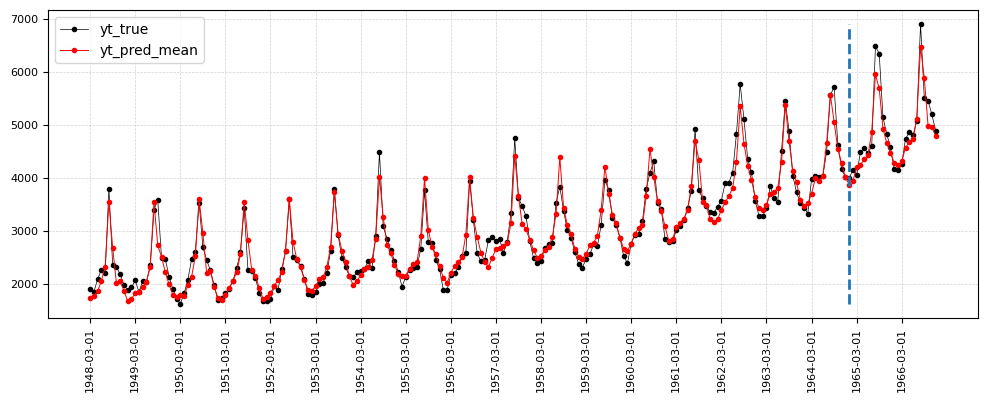

In [1]:
# %%
# =============================================================================
#
# Combinación de pronosticos
#
# =============================================================================
import warnings

warnings.filterwarnings("ignore")

#
# Carga de datos
#
import nbimporter  #  type: ignore
import functions  #  type: ignore

import pandas as pd  #  type: ignore

#
# Promedio de los pronosticos
#
df_orig = pd.read_csv("../files/output/forecasts.csv")
df_dropna = df_orig.dropna()
df_dropna = df_dropna.set_index("date")
df_dropna["yt_pred_mean"] = df_dropna.mean(axis=1)
functions.plot_time_series(df=df_dropna[["yt_true", "yt_pred_mean"]], yt_col="yt_true")











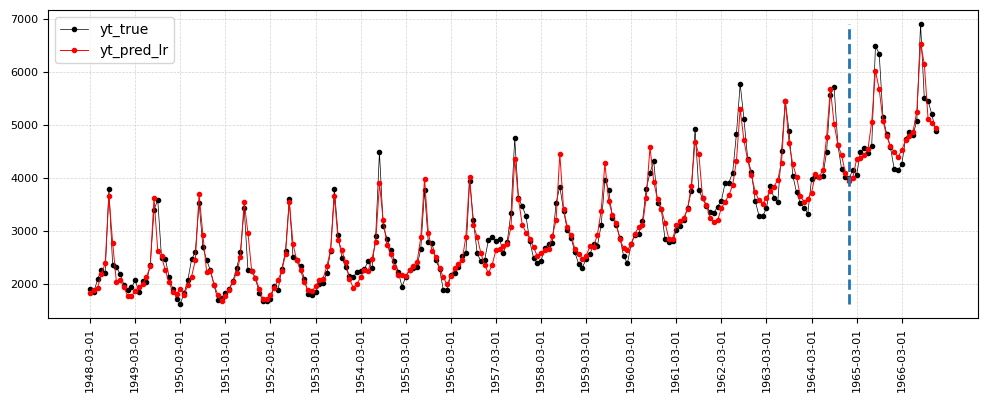

In [2]:

# %%
#
# Promedio de los pronosticos
#
from sklearn.linear_model import LinearRegression

model = LinearRegression()
X = df_dropna.drop(columns=["yt_true", "yt_pred_mean"])
y = df_dropna["yt_true"]
model.fit(X, y)
df_dropna["yt_pred_lr"] = model.predict(X)
functions.plot_time_series(df=df_dropna[["yt_true", "yt_pred_lr"]], yt_col="yt_true")




In [3]:
metrics = functions.compute_evaluation_metrics(df_orig.dropna())
metrics


,Metrics,yt_pred_time_trend_1_dummy,yt_pred_time_trend_2_dummy,yt_pred_time_trend_3_dummy,yt_pred_time_trend_3_fourier,yt_pred_d1d13_ar13,yt_pred_d1d12_mlp
0,MSE Train,103171.99,69047.49,65508.08,72984.78,66646.65,116706.35
1,MSE Test,738282.04,190079.09,107356.45,122981.45,138815.45,208249.12
2,MAE Train,254.42,200.59,194.71,204.79,188.42,237.88
3,MAE Test,804.13,341.66,262.00,278.01,267.05,302.35
